# 04 - Retrieval error analysis: where and why does retrieval miss?

Aggregate retrieval scores say *how often* it fails. This notebook says *how*: it runs the real
retriever (hybrid, no reranker, filters on) over every gold question that has gold sources and
sorts each result into a failure bucket, so fixes can be aimed at a cause instead of a number.

Relevance is defined at **(company, fiscal year, Item)** level, so a "miss" means none of the top-8
chunks came from the right section of the right filing.

Caveat carried through the whole notebook: `gold_v1` questions are templated and auto-derived
(docs/EVALUATION.md 2.1), and only 44 have gold sources. Read every per-group number as an
indication, not an estimate.

*Skills shown: error analysis, evaluation diagnostics, pandas.*

In [1]:
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "axes.titleweight": "bold", "axes.titlesize": 12,
})
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)

import numpy as np
from finsight.config.settings import get_settings
from finsight.core.filters import RetrievalFilters
from finsight.evaluation.datasets import load_gold
from finsight.evaluation.metrics.retrieval import matches_source, score_ranking
from finsight.evaluation.runner import run_retrieval_eval
from finsight.evaluation.stats import bootstrap_ci
from finsight.stack import load_stack

settings = get_settings()
gold = [e for e in load_gold(settings.eval_dir / "gold_v1.jsonl") if e.gold_sources]
print(f"{len(gold)} questions with gold sources "
      f"(dev {sum(e.split == 'dev' for e in gold)}, test {sum(e.split == 'test' for e in gold)}); "
      f"retrieval mode={settings.retrieval.mode}, rerank={settings.retrieval.rerank}, k=8")

44 questions with gold sources (dev 29, test 15); retrieval mode=hybrid, rerank=False, k=8


## 1. Run the retriever and keep the evidence

For each question keep: the gold sections, the top-8 `(ticker, year, Item)` triples, the filters the
query analyser derived, and the rank of the first relevant chunk. As a *diagnostic only* (never a
tuning input), each miss is re-run with the **Item filter removed** to see whether the filter or the
ranking was at fault.

In [2]:
K = 8
records = []
with load_stack(settings) as stack:
    retriever = stack.retriever()
    ref_rows = {r.example_id: r for r in run_retrieval_eval(retriever, gold)}
    for ex in gold:
        res = retriever.retrieve(ex.question, k=K)
        ranked = [r.chunk for r in res.chunks]
        sc = score_ranking(ranked, ex.gold_sources)
        first = next((i for i, c in enumerate(ranked, 1) if any(matches_source(c, s) for s in ex.gold_sources)), None)
        gold_filings = {(s.ticker, s.fiscal_year) for s in ex.gold_sources}
        retrieved = [(c.metadata.ticker, c.metadata.fiscal_year, c.metadata.item) for c in ranked]
        right_filing = any((t, y) in gold_filings for t, y, _ in retrieved)
        item_filter = tuple(res.filters.items)
        gold_items = {s.item for s in ex.gold_sources}
        # Diagnostic (misses only): pin the search to the gold company-year and look 50 deep. Where
        # does the gold Item rank *inside its own filing*, and which Item wins instead?
        depth_rank, winner = None, None
        if first is None:
            src = ex.gold_sources[0]
            pinned = RetrievalFilters(tickers=(src.ticker,), fiscal_years=(src.fiscal_year,))
            deep = [r.chunk for r in retriever.retrieve(ex.question, k=50, filters=pinned).chunks]
            depth_rank = next((i for i, c in enumerate(deep, 1) if any(matches_source(c, s) for s in ex.gold_sources)), None)
            winner = deep[0].metadata.item if deep else None
        records.append(dict(
            id=ex.id, split=ex.split, type=ex.type.value, question=ex.question,
            ticker=ex.gold_sources[0].ticker, year=ex.gold_sources[0].fiscal_year,
            gold_items="/".join(sorted(str(i) for i in gold_items)), first_rank=first,
            hit1=sc.hit[1], hit8=sc.hit[8], recall8=sc.recall[8], mrr=sc.mrr,
            right_filing=right_filing, item_filter="/".join(item_filter) or "-",
            filter_excluded_gold=bool(item_filter) and not (gold_items & set(item_filter)),
            rank_in_own_filing=depth_rank, winning_item=winner,
            top_items=", ".join(f"{t} {y} It{i}" for t, y, i in retrieved[:4]),
        ))
df = pd.DataFrame(records)
# The notebook's scoring must equal the harness's, or one of them is wrong.
for split in ("dev", "test"):
    mine = df[df.split == split].recall8.mean()
    ref = np.mean([ref_rows[i].scores["recall@8"] for i in df[df.split == split].id])
    assert abs(mine - ref) < 1e-9, (split, mine, ref)
print("notebook scoring == evaluation harness scoring on both splits")

notebook scoring == evaluation harness scoring on both splits


## 2. Headline: dev vs test

The dev split was used to choose the retrieval defaults; test was not. The gap between them is the honest generalisation estimate.

In [3]:
rows = []
for split, g in df.groupby("split"):
    for metric in ("hit1", "hit8", "recall8", "mrr"):
        ci = bootstrap_ci(g[metric].tolist())
        rows.append(dict(split=split, n=len(g), metric=metric, mean=round(ci.mean, 3), ci_low=round(ci.lo, 3), ci_high=round(ci.hi, 3)))
tbl = pd.DataFrame(rows).pivot(index="metric", columns="split", values=["mean", "ci_low", "ci_high"])
display(tbl)
d, t = df[df.split == "dev"].recall8.mean(), df[df.split == "test"].recall8.mean()
print(f"recall@8: dev {d:.3f} vs test {t:.3f} (gap {d - t:+.3f}); the intervals above show how much of that gap is noise at this n.")

mean        ci_low        ci_high       
split      dev   test    dev   test     dev   test
metric                                            
hit1     0.483  0.400  0.310  0.133   0.655  0.667
hit8     0.897  0.600  0.793  0.333   1.000  0.867
mrr      0.614  0.445  0.469  0.219   0.755  0.686
recall8  0.897  0.567  0.793  0.333   1.000  0.800

recall@8: dev 0.897 vs test 0.567 (gap +0.330); the intervals above show how much of that gap is noise at this n.


## 3. Failure buckets

Every question lands in exactly one bucket: found at rank 1, found at ranks 2-8, missed but the **right filing** is in the top 8 (a section-level error), or missed with **no chunk from the right filing** (a filing-level error - the more serious kind).

split,dev,test,all
bucket,,,
1 found at rank 1,14,6,20
2 found at rank 2-8,12,3,15
"3 miss: right filing, wrong section",3,6,9


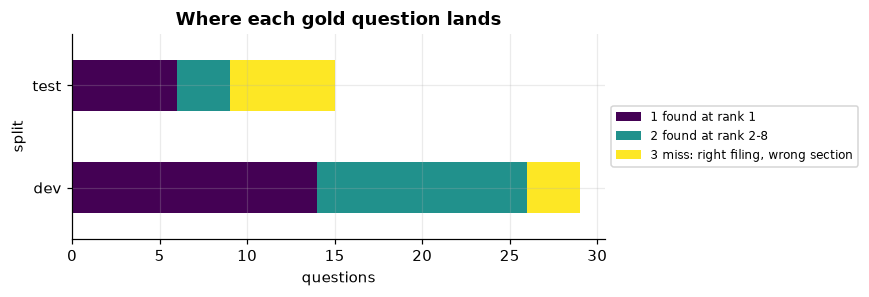

9 misses in total; 9 retrieved the right filing but the wrong section, 0 retrieved no chunk from the right filing.


In [4]:
def bucket(r):
    if pd.isna(r.first_rank): pass
    elif r.first_rank == 1: return "1 found at rank 1"
    else: return "2 found at rank 2-8"
    return "3 miss: right filing, wrong section" if r.right_filing else "4 miss: wrong filing"
df["bucket"] = df.apply(bucket, axis=1)
counts = df.groupby(["bucket", "split"]).size().unstack(fill_value=0)
counts["all"] = counts.sum(axis=1)
display(counts)
ax = counts[["dev", "test"]].T.plot.barh(stacked=True, figsize=(8, 2.8), colormap="viridis")
ax.set_xlabel("questions"); ax.set_title("Where each gold question lands"); ax.legend(loc="center left", bbox_to_anchor=(1, .5), fontsize=8)
plt.tight_layout(); plt.show()
n_miss = int(df.first_rank.isna().sum())
n_sec = int((df.bucket == "3 miss: right filing, wrong section").sum())
assert n_miss == int(df.bucket.str.startswith(("3", "4")).sum()) == int((df.hit8 == 0).sum())  # buckets agree with the metric
print(f"{n_miss} misses in total; {n_sec} retrieved the right filing but the wrong section, {n_miss - n_sec} retrieved no chunk from the right filing.")

## 4. Who fails? By company, question type and gold Item

In [5]:
def hit_table(col):
    g = df.groupby(col).agg(n=("id", "size"), hit8=("hit8", "mean"), recall8=("recall8", "mean"), mrr=("mrr", "mean")).round(3)
    return g.sort_values("hit8")
for col in ("ticker", "type", "gold_items"):
    print(f"--- by {col}"); display(hit_table(col).head(8))

--- by ticker


,n,hit8,recall8,mrr
ticker,,,,
WMT,4,0.250,0.250,0.250
JPM,4,0.500,0.500,0.333
JNJ,3,0.667,0.667,0.667
TSLA,3,0.667,0.667,0.500
NVDA,4,0.750,0.750,0.536
XOM,4,0.750,0.750,0.383
AAPL,4,1.000,1.000,0.521
AMZN,3,1.000,1.000,0.833


--- by type


,n,hit8,recall8,mrr
type,,,,
change_detection,8,0.75,0.688,0.466
fact_lookup,16,0.75,0.750,0.421
qualitative,20,0.85,0.850,0.700


--- by gold_items


,n,hit8,recall8,mrr
gold_items,,,,
1,5,0.600,0.600,0.333
7A,7,0.714,0.714,0.714
3,8,0.750,0.750,0.562
1A,15,0.800,0.767,0.449
2,3,1.000,1.000,0.189
7,6,1.000,1.000,1.000


## 5. Every miss, with the evidence

`item_filter` is what the query analyser inferred from the wording; `top_items` are the sections that actually came back.

In [6]:
misses = df[df.first_rank.isna()][["id", "split", "ticker", "year", "gold_items", "item_filter", "rank_in_own_filing", "winning_item", "top_items", "question"]]
with pd.option_context("display.max_colwidth", 70):
    display(misses.reset_index(drop=True))

,id,split,ticker,year,gold_items,item_filter,rank_in_own_filing,winning_item,top_items,question
0,chg-0030,dev,NVDA,2023,1A,-,9.0,1,"NVDA 2022 It7, NVDA 2023 It1, NVDA 2022 It15, NVDA 2023 It7",What new risks did Nvidia add to its fiscal 2023 risk factors comp...
1,sec-0058,dev,TSLA,2025,1,-,16.0,7,"TSLA 2025 It7, TSLA 2025 It7, TSLA 2025 It7, TSLA 2025 It8",Describe Tesla's business as presented in its fiscal 2025 annual r...
2,sec-0065,test,JPM,2023,3,-,9.0,15,"JPM 2023 It15, JPM 2023 It15, JPM 2023 It15, JPM 2023 It15",What legal proceedings does JPMorgan describe in its fiscal 2023 1...
3,sec-0066,test,JPM,2025,7A,-,44.0,15,"JPM 2025 It15, JPM 2025 It15, JPM 2025 It15, JPM 2025 It15","What does JPMorgan say about market risk, such as interest rate an..."
4,sec-0077,dev,XOM,2023,7A,-,13.0,16,"XOM 2023 It16, XOM 2023 It16, XOM 2023 It16, XOM 2023 It16","What does Exxon say about market risk, such as interest rate and c..."
5,sec-0086,test,JNJ,2022,3,-,14.0,7,"JNJ 2022 It7, JNJ 2022 It7, JNJ 2022 It8, JNJ 2022 It8",What legal proceedings does J&J describe in its fiscal 2022 10-K?
6,sec-0104,test,WMT,2023,1A,-,17.0,7,"WMT 2023 It7, WMT 2023 It7, WMT 2023 It7, WMT 2023 It7",What are the main risk factors Walmart discloses in its fiscal 202...
7,sec-0105,test,WMT,2024,1,-,28.0,7,"WMT 2024 It7, WMT 2024 It7, WMT 2024 It8, WMT 2024 It8",Describe Walmart's business as presented in its fiscal 2024 annual...
8,chg-0107,test,WMT,2023,1A,-,17.0,7,"WMT 2023 It7, WMT 2023 It7, WMT 2023 It7, WMT 2023 It7",What new risks did Walmart add to its fiscal 2023 risk factors com...


## 6. Diagnosis: was it the filter, or the ranking?\n\nTwo checks on the misses. (a) Did the query analyser apply an Item filter that could have excluded the gold section? (b) With the search pinned to the gold company-year and 50 results deep, where does the gold Item rank *inside its own filing*, and which Item wins instead? A large `rank_in_own_filing` means the section is hard to reach; `None` means it is not in the top 50 of its own filing at all.

In [7]:
miss = df[df.first_rank.isna()]
print(f"(a) misses where an Item filter was applied: {int((miss.item_filter != '-').sum())} of {len(miss)}"
      f" -> the Item filter is {'the cause' if (miss.filter_excluded_gold).any() else 'not the cause of any miss'}")
r = miss.rank_in_own_filing
print(f"(b) gold Item found within its own filing's top 50: {int(r.notna().sum())} of {len(miss)}; "
      f"median rank when found {r.median() if r.notna().any() else float('nan')}")
print("    Item that beat the gold Item most often:", miss.winning_item.value_counts().to_dict())
display(miss[["id", "ticker", "year", "gold_items", "winning_item", "rank_in_own_filing"]].reset_index(drop=True))

(a) misses where an Item filter was applied: 0 of 9 -> the Item filter is not the cause of any miss
(b) gold Item found within its own filing's top 50: 9 of 9; median rank when found 16.0
    Item that beat the gold Item most often: {'7': 5, '15': 2, '1': 1, '16': 1}


,id,ticker,year,gold_items,winning_item,rank_in_own_filing
0,chg-0030,NVDA,2023,1A,1,9.0
1,sec-0058,TSLA,2025,1,7,16.0
2,sec-0065,JPM,2023,3,15,9.0
3,sec-0066,JPM,2025,7A,15,44.0
4,sec-0077,XOM,2023,7A,16,13.0
5,sec-0086,JNJ,2022,3,7,14.0
6,sec-0104,WMT,2023,1A,7,17.0
7,sec-0105,WMT,2024,1,7,28.0
8,chg-0107,WMT,2023,1A,7,17.0


## 7. The bank layout effect (JPM)

JPMorgan files its MD&A and statements in an appended annual report that sits under **Item 15**, so an `Item 7` filter cannot reach them (see notebook 02). Here is how JPM questions fare compared with everyone else.

In [8]:
df["is_jpm"] = df.ticker == "JPM"
cmp = df.groupby("is_jpm").agg(n=("id", "size"), hit8=("hit8", "mean"), recall8=("recall8", "mean"), item_filter_excluded_gold=("filter_excluded_gold", "mean")).round(3)
cmp.index = ["other 11 companies", "JPM"]
display(cmp)
print("JPM questions:"); display(df[df.is_jpm][["id", "split", "gold_items", "item_filter", "hit8", "top_items"]].reset_index(drop=True))

,n,hit8,recall8,item_filter_excluded_gold
other 11 companies,40,0.825,0.812,0.0
JPM,4,0.500,0.500,0.0


JPM questions:


,id,split,gold_items,item_filter,hit8,top_items
0,sec-0065,test,3,-,0.0,"JPM 2023 It15, JPM 2023 It15, JPM 2023 It15, J..."
1,sec-0066,test,7A,-,0.0,"JPM 2025 It15, JPM 2025 It15, JPM 2025 It15, J..."
2,sec-0067,test,1A,-,1.0,"JPM 2024 It15, JPM 2024 It15, JPM 2024 It1A, J..."
3,chg-0068,test,1A,-,1.0,"JPM 2024 It1A, JPM 2024 It1A, JPM 2025 It15, J..."


Are the JPM misses really wrong, or is the right text just filed under a different Item? Read what the top three chunks actually say:

In [9]:
with load_stack(settings) as stack:
    retriever = stack.retriever()
    for _, row in df[df.is_jpm & (df.hit8 == 0)].iterrows():
        print(f"{row.id} (gold Item {row.gold_items}): {row.question}")
        for r in retriever.retrieve(row.question, k=3).chunks:
            m = r.chunk.metadata
            print(f"   Item {m.item}: {r.chunk.text[:210].replace(chr(10), ' ')!r}")
        print()

sec-0065 (gold Item 3): What legal proceedings does JPMorgan describe in its fiscal 2023 10-K?


   Item 15: 'The Firm’s legal expense was $1.4 billion, $266 million and $426 million for the years ended December 31, 2023, 2022 and 2021, respectively. There is no assurance that the Firm’s litigation reserves will not ne'
   Item 15: 'In addition to the various legal proceedings discussed above, JPMorgan Chase and its subsidiaries are named as defendants or are otherwise involved in a substantial number of other legal proceedings. The Firm b'
   Item 15: 'EXECUTIVE OVERVIEW  This executive overview of the MD&A highlights selected information and does not contain all of the information that is important to readers of the Firm’s 2023 Form 10-K. For a complete desc'

sec-0066 (gold Item 7A): What does JPMorgan say about market risk, such as interest rate and currency exposure, in fiscal 2025?
   Item 15: 'Notes to consolidated financial statements  The weighted-average contractual interest rates for total long-term debt excluding structured notes accounted for at fair value were 3.89% 

## What to take from this (and what not to)

* The tables and printed counts above are computed from the live index on every build. The
  sentences below describe the build committed with this notebook: re-read them against the
  outputs if the index or the gold set changes.
* **Every miss retrieved the right filing, and the gold section was reachable inside it** (section 6).
  The failures are section-level ranking errors, most often MD&A (Item 7) outranking the gold Item.
* **Some misses are partly a scoring artifact.** Relevance is judged by Item label, and JPM files
  the relevant text under Item 15. The JPM cell above shows the retrieved chunks - read them to
  judge how many "misses" were actually the right text under a different label. It is not a
  clean win either way, which is why the project treats section-level hit rate as a coarse proxy.
* **Section-level misses are cheap to fix and expensive to over-fit.** A per-company Item map or a
  wider Item filter would raise these numbers, but the fixes would be derived from the very
  questions being scored. The project deliberately did *not* tune against the test failures; the
  honest next step is a fresh, human-verified gold set (`gold_v2`) to measure any such change on.
* The judged unit (company-year-Item) is coarser than an answer span. A section hit does not
  prove the answer sentence was retrieved; passage-level gold labels would be the stricter test.